In [2]:
import pandas as pd
import numpy as np
import requests
import time

# ════════════════════════════════════════════════════════════
# STEP 1: LOAD & MERGE FSI FILES
# ════════════════════════════════════════════════════════════

df2019 = pd.read_excel("fsi-2019.xlsx")
df2020 = pd.read_excel("fsi-2020.xlsx")
df2021 = pd.read_excel("fsi-2021.xlsx")

# Strip whitespace from column names
for df in [df2019, df2020, df2021]:
    df.columns = df.columns.str.strip()

# Drop "Change from Previous Year" from 2019 & 2020
for df in [df2019, df2020]:
    drop_cols = [c for c in df.columns if "change" in c.lower()]
    df.drop(columns=drop_cols, inplace=True)

# Add year
df2019["Year"] = 2019
df2020["Year"] = 2020
df2021["Year"] = 2021

# Merge
df = pd.concat([df2019, df2020, df2021], ignore_index=True)

# Rename columns
df.rename(columns={
    "Total"                             : "FSI",
    "C1: Security Apparatus"            : "C1",
    "C2: Factionalized Elites"          : "C2",
    "C3: Group Grievance"               : "C3",
    "E1: Economy"                       : "E1",
    "E2: Economic Inequality"           : "E2",
    "E3: Human Flight and Brain Drain"  : "E3",
    "P1: State Legitimacy"              : "P1",
    "P2: Public Services"               : "P2",
    "P3: Human Rights"                  : "P3",
    "S1: Demographic Pressures"         : "S1",
    "S2: Refugees and IDPs"             : "S2",
    "X1: External Intervention"         : "X1"
}, inplace=True)

# Fix Year column — 2019 & 2020 stored as datetime, 2021 as int
df["Year"] = df["Year"].apply(
    lambda x: x.year if hasattr(x, "year") else int(x)
)

print(f"Merged shape : {df.shape}")
print(f"Years        : {sorted(df['Year'].unique())}")
print(f"Countries    : {df['Country'].nunique()}")

Merged shape : (535, 16)
Years        : [np.int64(2019), np.int64(2020), np.int64(2021)]
Countries    : 186


In [13]:
# Save merged FSI dataset with all features
df.to_csv("fsi_merged_complete.csv", index=False)
files.download("fsi_merged_complete.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ════════════════════════════════════════════════════════════
# STEP 2: STANDARDIZE COUNTRY NAMES
# (FSI uses different names across years — fix to one standard)
# ════════════════════════════════════════════════════════════

# These are countries that appear under TWO names across the 3 years
FSI_STANDARD = {
    # Old name            → Standard name (use 2021 version)
    "Cape Verde"          : "Cabo Verde",
    "Swaziland"           : "Eswatini",
    "Czech Republic"      : "Czechia",
    "Slovakia"            : "Slovak Republic",
    "Kyrgyzstan"          : "Kyrgyz Republic",
    "Macedonia"           : "North Macedonia",
    "South Korea"         : "Korea, Rep.",
    "North Korea"         : "Korea, Dem. People's Rep.",
    "Russia"              : "Russian Federation",
    "Vietnam"             : "Viet Nam",
    "Laos"                : "Lao PDR",
    "Syria"               : "Syrian Arab Republic",
    "Iran"                : "Iran, Islamic Rep.",
    "Egypt"               : "Egypt, Arab Rep.",
    "Yemen"               : "Yemen, Rep.",
    "Venezuela"           : "Venezuela, RB",
    "Turkey"              : "Turkiye",
    "Gambia"              : "Gambia, The",
    "Bahamas"             : "Bahamas, The",
    "Congo Democratic Republic" : "Congo, Dem. Rep.",
    "Congo Republic"      : "Congo, Rep.",
    "Guinea Bissau"       : "Guinea-Bissau",
    "Micronesia"          : "Micronesia, Fed. Sts.",
    "Palestine"           : "West Bank and Gaza",
    "Israel and West Bank": "West Bank and Gaza",
}

# Apply standardization
df["Country"] = df["Country"].replace(FSI_STANDARD)

print("Country count after standardization:", df["Country"].nunique())
print("\nSample standardized:")
print(df[["Country","Year","FSI"]].head(5))

Country count after standardization: 179

Sample standardized:
                Country  Year    FSI
0           Yemen, Rep.  2019  113.5
1               Somalia  2019  112.3
2           South Sudan  2019  112.2
3  Syrian Arab Republic  2019  111.5
4      Congo, Dem. Rep.  2019  110.2


In [40]:
# ════════════════════════════════════════════════════════════
# STEP 3: FETCH WORLD BANK DATA
# ════════════════════════════════════════════════════════════

INDICATORS = {
    "GDP_per_Capita"     : "NY.GDP.PCAP.CD",
    "Corruption_Control" : "CC.EST",
    "Internet_Access"    : "IT.NET.USER.ZS",
    "Infant_Mortality"   : "SP.DYN.IMRT.IN"
}

def fetch_wb_indicator(indicator_code, years=(2019, 2020, 2021)):
    url    = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {"format": "json", "per_page": 10000,
              "date": f"{min(years)}:{max(years)}"}
    try:
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"  ERROR: {e}")
        return {}

    if len(data) < 2 or data[1] is None:
        return {}

    result = {}
    for entry in data[1]:
        if entry["value"] is not None:
            name = entry["country"]["value"]
            iso3 = entry["countryiso3code"]
            year = int(entry["date"])
            result[(name, year)] = entry["value"]
            result[(iso3, year)] = entry["value"]   # ISO3 backup
    return result

print("Fetching World Bank data...")
print("-" * 45)
wb_data = {}
for feat, code in INDICATORS.items():
    print(f"  Fetching {feat}...")
    wb_data[feat] = fetch_wb_indicator(code)
    print(f"    → {len(wb_data[feat])} records")
    time.sleep(1)
print("Done.")

Fetching World Bank data...
---------------------------------------------
  Fetching GDP_per_Capita...
    → 1541 records
  Fetching Corruption_Control...
    → 0 records
  Fetching Internet_Access...
    → 1295 records
  Fetching Infant_Mortality...
    → 1455 records
Done.


In [41]:
# ════════════════════════════════════════════════════════════
# STEP 4: MAP WORLD BANK DATA ONTO FSI DATASET
# Now this is SIMPLE because country names are already
# standardized to World Bank format in STEP 2
# ════════════════════════════════════════════════════════════

new_features = ["GDP_per_Capita", "Corruption_Control",
                "Internet_Access", "Infant_Mortality"]

for feat in new_features:
    df[feat] = df.apply(
        lambda row, f=feat: wb_data[f].get(
            (row["Country"], row["Year"]), np.nan
        ),
        axis=1
    )

# ── Coverage report ──────────────────────────────────────────
print("Coverage Report:")
print("=" * 50)
for feat in new_features:
    found   = df[feat].notna().sum()
    total   = len(df)
    missing = sorted(df[df[feat].isna()]["Country"].unique())
    print(f"\n{feat}:")
    print(f"  Matched : {found}/{total} ({found/total*100:.1f}%)")
    if missing:
        print(f"  Missing : {missing}")

Coverage Report:

GDP_per_Capita:
  Matched : 519/535 (97.0%)
  Missing : ['Cuba', 'Eritrea', "Korea, Dem. People's Rep.", 'Somalia', 'South Sudan', 'Yemen, Rep.']

Corruption_Control:
  Matched : 0/535 (0.0%)
  Missing : ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gab

In [42]:
# ════════════════════════════════════════════════════════════
# FIX: Re-fetch Corruption_Control using correct WGI endpoint
# ════════════════════════════════════════════════════════════

def fetch_wgi_corruption(years=(2019, 2020, 2021)):
    """
    World Governance Indicators use a different endpoint format.
    CC.EST = Control of Corruption estimate
    """
    result = {}

    for year in years:
        url = "https://api.worldbank.org/v2/country/all/indicator/CC.EST"
        params = {
            "format"   : "json",
            "per_page" : 500,
            "date"     : str(year)
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()

            if len(data) < 2 or data[1] is None:
                print(f"  No data for year {year}")
                continue

            count = 0
            for entry in data[1]:
                if entry["value"] is not None:
                    name = entry["country"]["value"]
                    iso3 = entry["countryiso3code"]
                    result[(name, year)] = entry["value"]
                    result[(iso3, year)] = entry["value"]
                    count += 1
            print(f"  Year {year}: {count} records fetched")

        except Exception as e:
            print(f"  ERROR year {year}: {e}")

        time.sleep(0.5)

    return result

print("Re-fetching Corruption_Control...")
wb_data["Corruption_Control"] = fetch_wgi_corruption()
print(f"Total records: {len(wb_data['Corruption_Control'])}")

# ── Quick check — print sample keys ─────────────────────────────────────────
print("\nSample keys:")
for i, key in enumerate(list(wb_data["Corruption_Control"].keys())[:10]):
    print(f"  {key} → {wb_data['Corruption_Control'][key]:.4f}")

Re-fetching Corruption_Control...
  No data for year 2019
  No data for year 2020
  No data for year 2021
Total records: 0

Sample keys:


In [43]:
# ── Debug: inspect raw API response for CC.EST ──────────────────────────────

import requests

url = "https://api.worldbank.org/v2/country/all/indicator/CC.EST"
params = {
    "format"   : "json",
    "per_page" : 10,
    "date"     : "2020"
}

r = requests.get(url, params=params, timeout=30)
data = r.json()

print("Status code:", r.status_code)
print("Type of data[0]:", type(data[0]))
print("\ndata[0] (metadata):")
print(data[0])
print("\ndata[1] (first 3 entries):")
if data[1]:
    for entry in data[1][:3]:
        print(entry)
else:
    print("data[1] is None or empty")

Status code: 200
Type of data[0]: <class 'dict'>

data[0] (metadata):
{'message': [{'id': '175', 'key': 'Invalid format', 'value': 'The indicator was not found. It may have been deleted or archived.'}]}

data[1] (first 3 entries):


IndexError: list index out of range

In [44]:
# ── Find correct corruption indicator code ───────────────────────────────────

import requests

codes_to_test = [
    "CC.EST",              # old code — archived
    "CC.PER.RNK",          # percentile rank version
    "CC.PER.RNK.LOWER",
    "IQ.CPA.TRAN.XQ",      # CPIA transparency
    "IC.FRM.CORR.ZS",      # % firms experiencing corruption
    "GE.EST",              # Government Effectiveness (similar)
]

print("Testing indicator codes against World Bank API:")
print("-" * 55)

for code in codes_to_test:
    url = f"https://api.worldbank.org/v2/country/USA/indicator/{code}"
    params = {"format": "json", "per_page": 5, "date": "2020"}

    try:
        r = requests.get(url, params=params, timeout=15)
        data = r.json()

        if len(data) > 1 and data[1] and data[1][0]["value"] is not None:
            val = data[1][0]["value"]
            print(f"  {code:35} → ✓ WORKS  value={val:.4f}")
        elif len(data) > 0 and data[0].get("message"):
            msg = data[0]["message"][0]["value"]
            print(f"  {code:35} → ✗ {msg}")
        else:
            print(f"  {code:35} → ✗ No data")
    except Exception as e:
        print(f"  {code:35} → ERROR: {e}")

Testing indicator codes against World Bank API:
-------------------------------------------------------
  CC.EST                              → ✗ The indicator was not found. It may have been deleted or archived.
  CC.PER.RNK                          → ✗ The indicator was not found. It may have been deleted or archived.
  CC.PER.RNK.LOWER                    → ✗ The indicator was not found. It may have been deleted or archived.
  IQ.CPA.TRAN.XQ                      → ✗ No data
  IC.FRM.CORR.ZS                      → ✗ No data
  GE.EST                              → ✗ The indicator was not found. It may have been deleted or archived.


In [45]:
# ── Search World Bank for working governance/corruption indicators ────────────

import requests

# Search the WB indicator catalog for "corruption"
url = "https://api.worldbank.org/v2/indicator"
params = {
    "format"  : "json",
    "per_page": 500,
    "q"       : "corruption"
}

r = requests.get(url, params=params, timeout=30)
data = r.json()

print(f"Total indicators found: {data[0]['total']}")
print("\nIndicator codes and names:")
print("-" * 70)
for item in data[1]:
    print(f"  {item['id']:40} {item['name']}")

Total indicators found: 29511

Indicator codes and names:
----------------------------------------------------------------------
  1.0.HCount.1.90usd                       Poverty Headcount ($1.90 a day)
  1.0.HCount.2.5usd                        Poverty Headcount ($2.50 a day)
  1.0.HCount.Mid10to50                     Middle Class ($10-50 a day) Headcount
  1.0.HCount.Ofcl                          Official Moderate Poverty Rate-National
  1.0.HCount.Poor4uds                      Poverty Headcount ($4 a day)
  1.0.HCount.Vul4to10                      Vulnerable ($4-10 a day) Headcount
  1.0.PGap.1.90usd                         Poverty Gap ($1.90 a day)
  1.0.PGap.2.5usd                          Poverty Gap ($2.50 a day)
  1.0.PGap.Poor4uds                        Poverty Gap ($4 a day)
  1.0.PSev.1.90usd                         Poverty Severity ($1.90 a day)
  1.0.PSev.2.5usd                          Poverty Severity ($2.50 a day)
  1.0.PSev.Poor4uds                        Poverty Seve

In [46]:
# ── Test replacement indicators that actually work ───────────────────────────

import requests

candidates = {
    "NY.GDP.PCAP.CD"        : "GDP per Capita (already have)",
    "IT.NET.USER.ZS"        : "Internet Access (already have)",
    "SP.DYN.IMRT.IN"        : "Infant Mortality (already have)",
    "SL.UEM.TOTL.ZS"        : "Unemployment Rate (%)",
    "SE.ADT.LITR.ZS"        : "Adult Literacy Rate (%)",
    "SH.XPD.CHEX.GD.ZS"    : "Health Expenditure (% of GDP)",
    "MS.MIL.XPND.GD.ZS"    : "Military Expenditure (% of GDP)",
    "SP.URB.TOTL.IN.ZS"     : "Urban Population (%)",
    "SH.DYN.AIDS.ZS"        : "HIV Prevalence (%)",
    "NY.GNP.PCAP.CD"        : "GNI per Capita",
    "SI.POV.GINI"           : "GINI Inequality Index",
    "VC.IHR.PSRC.P5"        : "Intentional Homicides (per 100k)",
    "SP.POP.GROW"           : "Population Growth Rate (%)",
    "SE.PRM.NENR"           : "Primary School Enrollment (%)",
    "SH.STA.SUIC.P5"        : "Suicide Mortality Rate",
    "AG.LND.FRST.ZS"        : "Forest Area (% of land)",
    "EG.ELC.ACCS.ZS"        : "Access to Electricity (%)",
    "SH.H2O.SMDW.ZS"        : "Access to Safe Water (%)",
    "SP.DYN.LE00.IN"        : "Life Expectancy at Birth",
    "SE.SEC.ENRR"           : "Secondary School Enrollment (%)",
}

print("Testing indicators against World Bank API (USA, 2020):")
print("-" * 65)

working = {}
for code, name in candidates.items():
    url = f"https://api.worldbank.org/v2/country/USA/indicator/{code}"
    params = {"format": "json", "per_page": 5, "date": "2020"}
    try:
        r    = requests.get(url, params=params, timeout=15)
        data = r.json()
        if len(data) > 1 and data[1] and data[1][0]["value"] is not None:
            val = data[1][0]["value"]
            working[code] = name
            print(f"  ✓ {code:35} {name:40} = {val:.2f}")
        else:
            print(f"  ✗ {code:35} {name}")
    except Exception as e:
        print(f"  ! {code:35} ERROR: {e}")

Testing indicators against World Bank API (USA, 2020):
-----------------------------------------------------------------
  ✓ NY.GDP.PCAP.CD                      GDP per Capita (already have)            = 63515.95
  ✓ IT.NET.USER.ZS                      Internet Access (already have)           = 90.34
  ✓ SP.DYN.IMRT.IN                      Infant Mortality (already have)          = 5.50
  ✓ SL.UEM.TOTL.ZS                      Unemployment Rate (%)                    = 8.05
  ✗ SE.ADT.LITR.ZS                      Adult Literacy Rate (%)
  ✓ SH.XPD.CHEX.GD.ZS                   Health Expenditure (% of GDP)            = 18.52
  ✓ MS.MIL.XPND.GD.ZS                   Military Expenditure (% of GDP)          = 3.65
  ✓ SP.URB.TOTL.IN.ZS                   Urban Population (%)                     = 80.00
  ✗ SH.DYN.AIDS.ZS                      HIV Prevalence (%)
  ✓ NY.GNP.PCAP.CD                      GNI per Capita                           = 64920.00
  ✓ SI.POV.GINI                         G

In [1]:
# ════════════════════════════════════════════════════════════
# Replace Corruption_Control → Life Expectancy at Birth
# ════════════════════════════════════════════════════════════

# Update indicators dict
INDICATORS = {
    "GDP_per_Capita"     : "NY.GDP.PCAP.CD",
    "Life_Expectancy"    : "SP.DYN.LE00.IN",   # ← replaces Corruption_Control
    "Internet_Access"    : "IT.NET.USER.ZS",
    "Infant_Mortality"   : "SP.DYN.IMRT.IN"
}

# Update new_features list
new_features = ["GDP_per_Capita", "Life_Expectancy",
                "Internet_Access", "Infant_Mortality"]

# Fetch Life Expectancy fresh
print("Fetching Life_Expectancy...")
wb_data["Life_Expectancy"] = fetch_wb_indicator("SP.DYN.LE00.IN")
print(f"  → {len(wb_data['Life_Expectancy'])} records fetched")

# Apply to dataframe
df["Life_Expectancy"] = df.apply(
    lambda row: wb_data["Life_Expectancy"].get(
        (row["Country"], row["Year"]), np.nan
    ),
    axis=1
)

# Drop old Corruption_Control column if it exists
if "Corruption_Control" in df.columns:
    df.drop(columns=["Corruption_Control"], inplace=True)

# Coverage check
found   = df["Life_Expectancy"].notna().sum()
total   = len(df)
missing = sorted(df[df["Life_Expectancy"].isna()]["Country"].unique())
print(f"\nLife_Expectancy:")
print(f"  Matched : {found}/{total} ({found/total*100:.1f}%)")
if missing:
    print(f"  Missing : {missing}")
else:
    print(f"  ✓ No missing!")

Fetching Life_Expectancy...


NameError: name 'fetch_wb_indicator' is not defined

In [4]:
import requests
import time
import numpy as np

# ── Redefine fetch function ──────────────────────────────────────────────────
def fetch_wb_indicator(indicator_code, years=(2019, 2020, 2021)):
    url    = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {"format": "json", "per_page": 10000,
              "date"  : f"{min(years)}:{max(years)}"}
    try:
        r = requests.get(url, params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        print(f"  ERROR: {e}")
        return {}

    if len(data) < 2 or data[1] is None:
        return {}

    result = {}
    for entry in data[1]:
        if entry["value"] is not None:
            name = entry["country"]["value"]
            iso3 = entry["countryiso3code"]
            year = int(entry["date"])
            result[(name, year)] = entry["value"]
            result[(iso3, year)] = entry["value"]
    return result

# ── Update indicators & new_features ────────────────────────────────────────
INDICATORS = {
    "GDP_per_Capita"  : "NY.GDP.PCAP.CD",
    "Life_Expectancy" : "SP.DYN.LE00.IN",
    "Internet_Access" : "IT.NET.USER.ZS",
    "Infant_Mortality": "SP.DYN.IMRT.IN"
}

new_features = ["GDP_per_Capita", "Life_Expectancy",
                "Internet_Access", "Infant_Mortality"]

# ── Re-fetch ALL 4 indicators fresh ─────────────────────────────────────────
print("Fetching all indicators...")
print("-" * 45)
wb_data = {}
for feat, code in INDICATORS.items():
    print(f"  Fetching {feat}...")
    wb_data[feat] = fetch_wb_indicator(code)
    print(f"    → {len(wb_data[feat])} records")
    time.sleep(1)

print("\nDone fetching.")

# ── Apply all 4 to dataframe ─────────────────────────────────────────────────
print("\nMapping to dataframe...")
for feat in new_features:
    # Drop old column if exists
    if feat in df.columns:
        df.drop(columns=[feat], inplace=True)

    df[feat] = df.apply(
        lambda row, f=feat: wb_data[f].get(
            (row["Country"], row["Year"]), np.nan
        ),
        axis=1
    )

# Drop old Corruption_Control if still present
if "Corruption_Control" in df.columns:
    df.drop(columns=["Corruption_Control"], inplace=True)

# ── Coverage report ──────────────────────────────────────────────────────────
print("\nCoverage Report:")
print("=" * 50)
for feat in new_features:
    found   = df[feat].notna().sum()
    total   = len(df)
    missing = sorted(df[df[feat].isna()]["Country"].unique())
    print(f"\n{feat}:")
    print(f"  Matched : {found}/{total} ({found/total*100:.1f}%)")
    if missing:
        print(f"  Missing ({len(missing)}) : {missing}")
    else:
        print(f"  ✓ Perfect coverage!")

Fetching all indicators...
---------------------------------------------
  Fetching GDP_per_Capita...
    → 1541 records
  Fetching Life_Expectancy...
    → 1581 records
  Fetching Internet_Access...
    → 1295 records
  Fetching Infant_Mortality...
    → 1455 records

Done fetching.

Mapping to dataframe...

Coverage Report:

GDP_per_Capita:
  Matched : 519/535 (97.0%)
  Missing (6) : ['Cuba', 'Eritrea', "Korea, Dem. People's Rep.", 'Somalia', 'South Sudan', 'Yemen, Rep.']

Life_Expectancy:
  Matched : 532/535 (99.4%)
  Missing (1) : ['Somalia']

Internet_Access:
  Matched : 504/535 (94.2%)
  Missing (15) : ['Central African Republic', 'Eritrea', "Korea, Dem. People's Rep.", 'Micronesia, Fed. Sts.', 'Myanmar', 'Pakistan', 'Samoa', 'Somalia', 'South Sudan', 'Sudan', 'Suriname', 'Syrian Arab Republic', 'Turkmenistan', 'West Bank and Gaza', 'Yemen, Rep.']

Infant_Mortality:
  Matched : 532/535 (99.4%)
  Missing (1) : ['Somalia']


In [5]:
from sklearn.impute import SimpleImputer

# ── Define feature lists ─────────────────────────────────────────────────────
original_features = ["C1","C2","C3","E1","E2","E3",
                     "P1","P2","P3","S1","S2","X1"]

new_features = ["GDP_per_Capita", "Life_Expectancy",
                "Internet_Access", "Infant_Mortality"]

all_features = original_features + new_features

# ── Ensure original features are numeric ────────────────────────────────────
df[original_features] = df[original_features].apply(
    pd.to_numeric, errors="coerce"
)

# ── Median imputation ────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy="median")
df[original_features] = imputer.fit_transform(df[original_features])
df[new_features]      = imputer.fit_transform(df[new_features])

# ── Verify zero missing ──────────────────────────────────────────────────────
print("Missing values after imputation:")
print(df[all_features].isnull().sum().to_string())

print(f"\nFinal dataset shape : {df.shape}")
print(f"Countries           : {df['Country'].nunique()}")
print(f"Years               : {sorted(df['Year'].unique())}")

Missing values after imputation:
C1                  0
C2                  0
C3                  0
E1                  0
E2                  0
E3                  0
P1                  0
P2                  0
P3                  0
S1                  0
S2                  0
X1                  0
GDP_per_Capita      0
Life_Expectancy     0
Internet_Access     0
Infant_Mortality    0

Final dataset shape : (535, 20)
Countries           : 179
Years               : [np.int64(2019), np.int64(2020), np.int64(2021)]


In [6]:
# ════════════════════════════════════════════════════════════
# STEP: Discretize FSI → Decision Feature
# ════════════════════════════════════════════════════════════

def discretize_fsi(score):
    if   score >= 90: return "1_VeryHighAlert"
    elif score >= 80: return "2_HighAlert"
    elif score >= 70: return "3_Alert"
    elif score >= 60: return "4_HighWarning"
    elif score >= 50: return "5_Warning"
    elif score >= 40: return "6_Stable"
    elif score >= 30: return "7_MoreStable"
    elif score >= 20: return "8_Sustainable"
    else:             return "9_VerySustainable"

df["FSI_Category"] = df["FSI"].apply(discretize_fsi)

print("FSI Category distribution across all 3 years:")
print("-" * 45)
dist = df["FSI_Category"].value_counts().sort_index()
for cat, count in dist.items():
    bar = "█" * (count // 3)
    pct = count / len(df) * 100
    print(f"  {cat:<22} : {count:>4} ({pct:4.1f}%)  {bar}")

FSI Category distribution across all 3 years:
---------------------------------------------
  1_VeryHighAlert        :   91 (17.0%)  ██████████████████████████████
  2_HighAlert            :   80 (15.0%)  ██████████████████████████
  3_Alert                :   98 (18.3%)  ████████████████████████████████
  6_Stable               :   46 ( 8.6%)  ███████████████
  7_MoreStable           :   35 ( 6.5%)  ███████████
  8_Sustainable          :   30 ( 5.6%)  ██████████
  9_VerySustainable      :   23 ( 4.3%)  ███████


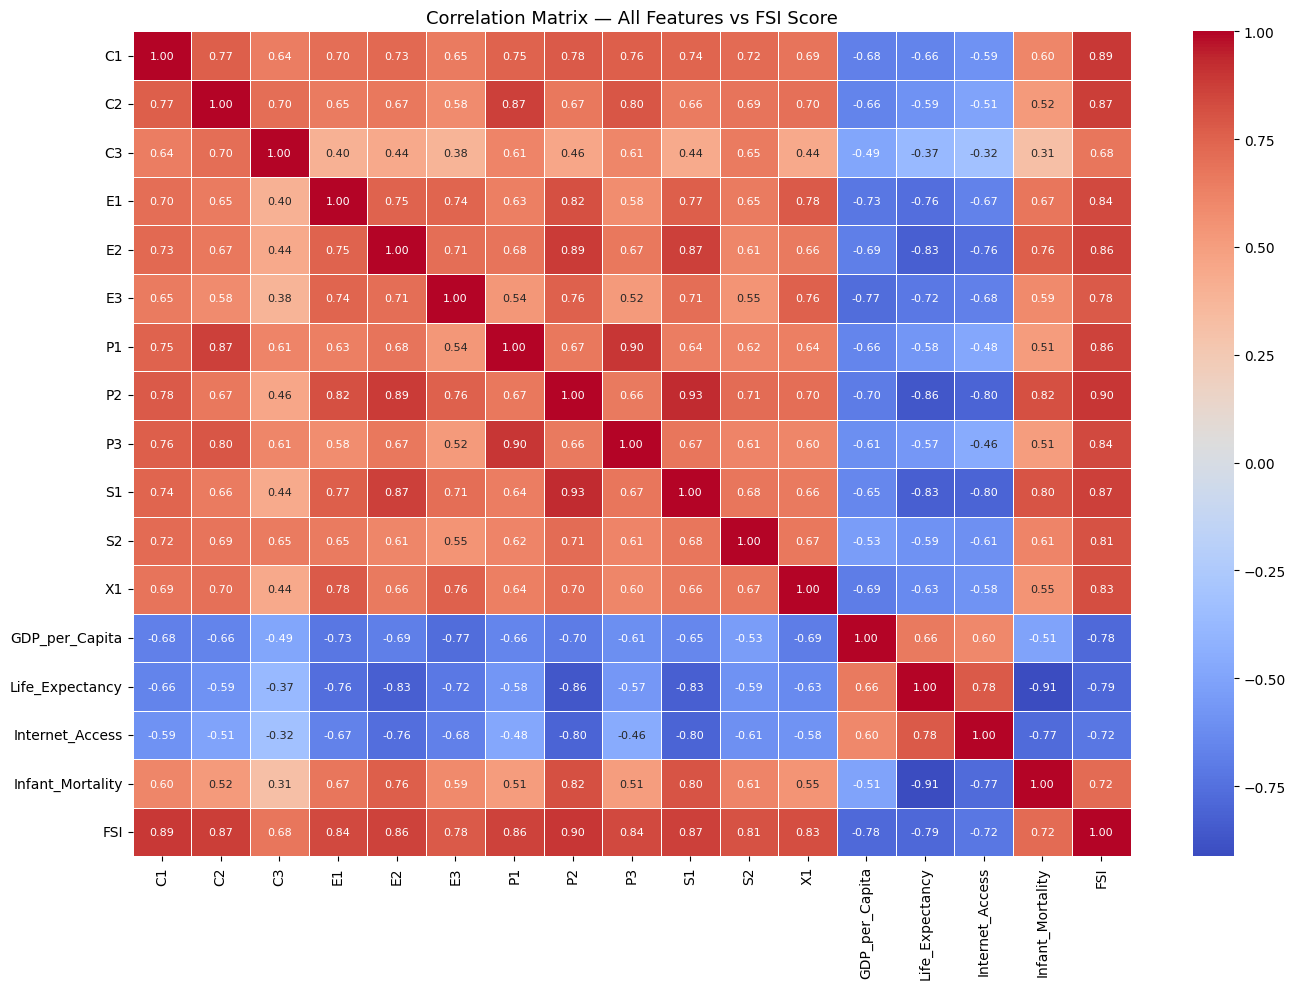

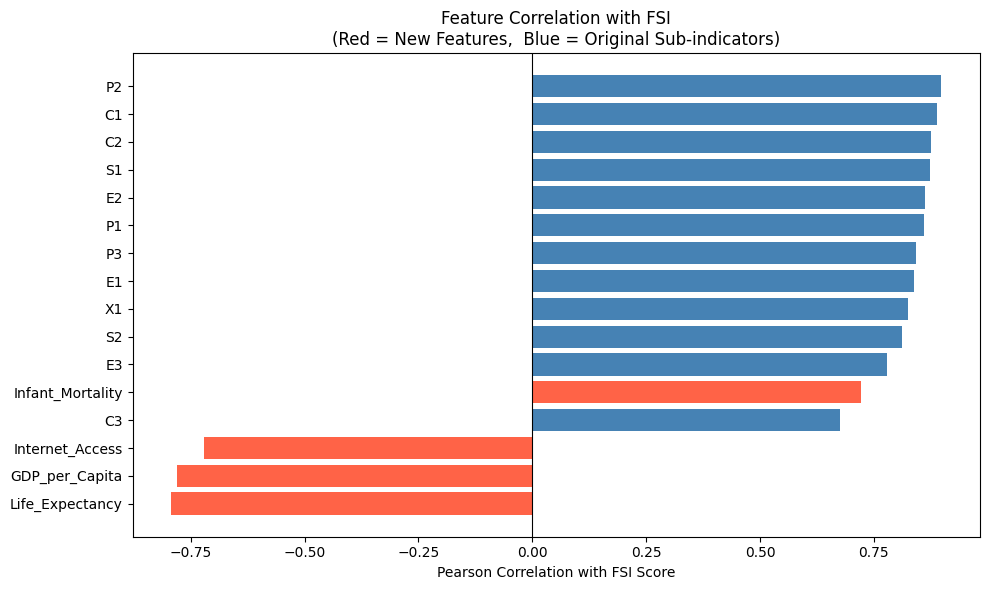

Correlations with FSI (strongest to weakest):
---------------------------------------------
  P2                        : +0.899
  C1                        : +0.889
  C2                        : +0.875
  S1                        : +0.873
  E2                        : +0.863
  P1                        : +0.859
  P3                        : +0.843
  E1                        : +0.839
  X1                        : +0.826
  S2                        : +0.813
  E3                        : +0.778
  Infant_Mortality          : +0.723 ← NEW
  C3                        : +0.677
  Internet_Access           : -0.722 ← NEW
  GDP_per_Capita            : -0.779 ← NEW
  Life_Expectancy           : -0.793 ← NEW


In [7]:
# ════════════════════════════════════════════════════════════
# STEP: Correlation Analysis
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import seaborn as sns

# ── Correlation heatmap ──────────────────────────────────────
corr = df[all_features + ["FSI"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="coolwarm", linewidths=0.5,
    annot_kws={"size": 8}
)
plt.title("Correlation Matrix — All Features vs FSI Score", fontsize=13)
plt.tight_layout()
plt.savefig("heatmap_all_features.png", dpi=150)
plt.show()

# ── Bar chart: each feature vs FSI ───────────────────────────
fsi_corr = corr["FSI"].drop("FSI").sort_values()

colors = ["tomato" if f in new_features else "steelblue"
          for f in fsi_corr.index]

plt.figure(figsize=(10, 6))
plt.barh(fsi_corr.index, fsi_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Pearson Correlation with FSI Score")
plt.title("Feature Correlation with FSI\n"
          "(Red = New Features,  Blue = Original Sub-indicators)")
plt.tight_layout()
plt.savefig("fsi_correlation_bar.png", dpi=150)
plt.show()

# ── Print correlation values ─────────────────────────────────
print("Correlations with FSI (strongest to weakest):")
print("-" * 45)
fsi_corr_sorted = corr["FSI"].drop("FSI").sort_values(ascending=False)
for feat, val in fsi_corr_sorted.items():
    tag = " ← NEW" if feat in new_features else ""
    print(f"  {feat:<25} : {val:+.3f}{tag}")

In [8]:
# ════════════════════════════════════════════════════════════
# STEP: Classification — With vs Without New Features
# ════════════════════════════════════════════════════════════
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.tree            import DecisionTreeClassifier, export_text
from sklearn.ensemble        import RandomForestClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.metrics         import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

# ── Encode target ────────────────────────────────────────────
le = LabelEncoder()
df["FSI_Label"] = le.fit_transform(df["FSI_Category"])

df_clean = df.dropna(subset=all_features + ["FSI_Label"]).copy()
print(f"Clean dataset : {df_clean.shape}")
print(f"Classes       : {list(le.classes_)}\n")

# ── Feature matrices ─────────────────────────────────────────
X_orig = df_clean[original_features].values
X_full = df_clean[all_features].values
y      = df_clean["FSI_Label"].values

# ── Scale ────────────────────────────────────────────────────
scaler    = StandardScaler()
X_orig_sc = scaler.fit_transform(X_orig)
X_full_sc = scaler.fit_transform(X_full)

# ── Train/test split ─────────────────────────────────────────
Xo_tr, Xo_te, y_tr, y_te = train_test_split(
    X_orig_sc, y, test_size=0.2, random_state=42, stratify=y)
Xf_tr, Xf_te, _,   _     = train_test_split(
    X_full_sc, y, test_size=0.2, random_state=42, stratify=y)

# ── Run classifiers ──────────────────────────────────────────
classifiers = {
    "Decision Tree" : DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest" : RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes"   : GaussianNB()
}

results = []

for name, clf in classifiers.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Without new features
    clf.fit(Xo_tr, y_tr)
    acc_orig = accuracy_score(y_te, clf.predict(Xo_te))

    # With new features
    clf.fit(Xf_tr, y_tr)
    pred_full = clf.predict(Xf_te)
    acc_full  = accuracy_score(y_te, pred_full)

    results.append({
        "Classifier"             : name,
        "Accuracy (Original)"    : round(acc_orig, 4),
        "Accuracy (+4 Features)" : round(acc_full, 4),
        "Improvement"            : round(acc_full - acc_orig, 4)
    })

    print(f"\n  WITHOUT new features : {acc_orig:.4f}")
    print(f"  WITH    new features : {acc_full:.4f}")
    print(f"\n  Classification Report (WITH new features):")
    print(classification_report(
        y_te, pred_full,
        target_names=le.classes_,
        digits=3
    ))

# ── Summary table ────────────────────────────────────────────
print("="*55)
print("  ACCURACY COMPARISON SUMMARY")
print("="*55)
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
res_df.to_csv("classification_comparison.csv", index=False)

Clean dataset : (535, 22)
Classes       : ['1_VeryHighAlert', '2_HighAlert', '3_Alert', '4_HighWarning', '5_Warning', '6_Stable', '7_MoreStable', '8_Sustainable', '9_VerySustainable']

  Decision Tree

  WITHOUT new features : 0.6542
  WITH    new features : 0.6262

  Classification Report (WITH new features):
                   precision    recall  f1-score   support

  1_VeryHighAlert      0.889     0.889     0.889        18
      2_HighAlert      0.733     0.688     0.710        16
          3_Alert      0.737     0.700     0.718        20
    4_HighWarning      0.538     0.438     0.483        16
        5_Warning      0.500     0.400     0.444        10
         6_Stable      0.364     0.889     0.516         9
     7_MoreStable      0.333     0.143     0.200         7
    8_Sustainable      1.000     0.333     0.500         6
9_VerySustainable      0.571     0.800     0.667         5

         accuracy                          0.626       107
        macro avg      0.630     0.58

|--- P2 <= 0.89
|   |--- GDP_per_Capita <= -0.19
|   |   |--- S2 <= -0.13
|   |   |   |--- GDP_per_Capita <= -0.60
|   |   |   |   |--- class: 2
|   |   |   |--- GDP_per_Capita >  -0.60
|   |   |   |   |--- GDP_per_Capita <= -0.35
|   |   |   |   |   |--- E2 <= 0.36
|   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |--- E2 >  0.36
|   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- GDP_per_Capita >  -0.35
|   |   |   |   |   |--- P1 <= -0.03
|   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |--- P1 >  -0.03
|   |   |   |   |   |   |--- class: 3
|   |   |--- S2 >  -0.13
|   |   |   |--- Internet_Access <= -0.77
|   |   |   |   |--- S2 <= 0.15
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- S2 >  0.15
|   |   |   |   |   |--- Internet_Access <= -1.86
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Internet_Access >  -1.86
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- Internet_Access >  -0.77
|   |   |   |   |--- P3 <= 0.53
|   |   |  

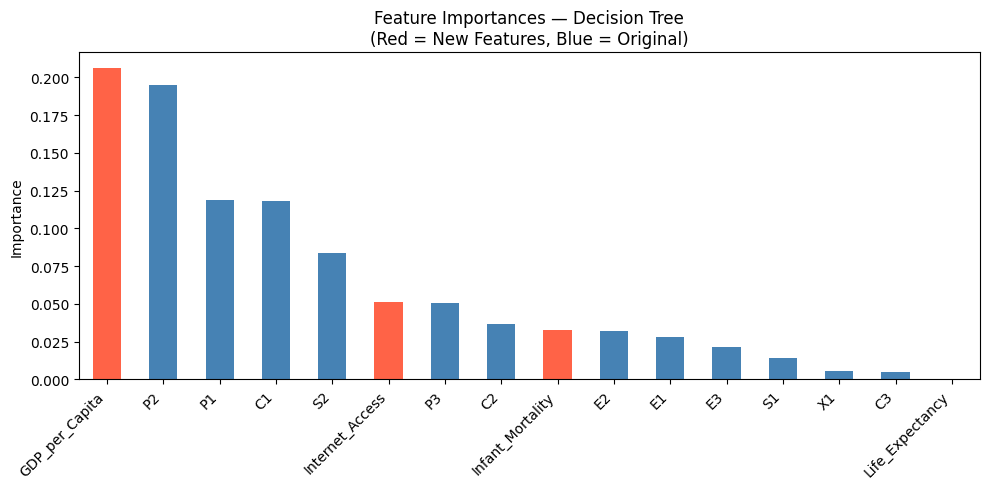


Top 8 most important features:
-----------------------------------
  GDP_per_Capita            : 0.2064 ← NEW
  P2                        : 0.1949
  P1                        : 0.1185
  C1                        : 0.1182
  S2                        : 0.0835
  Internet_Access           : 0.0515 ← NEW
  P3                        : 0.0509
  C2                        : 0.0368


In [9]:
# ════════════════════════════════════════════════════════════
# STEP: Extract Decision Tree Rules + Feature Importances
# ════════════════════════════════════════════════════════════

# ── Train final DT on full features ─────────────────────────
dt_final = DecisionTreeClassifier(max_depth=6, random_state=42)
dt_final.fit(Xf_tr, y_tr)

# ── Text rules ───────────────────────────────────────────────
rules = export_text(dt_final, feature_names=all_features)
print(rules)
with open("classification_rules.txt", "w") as f:
    f.write(rules)
print("Saved → classification_rules.txt")

# ── Feature importances ──────────────────────────────────────
importances = pd.Series(
    dt_final.feature_importances_,
    index=all_features
).sort_values(ascending=False)

colors = ["tomato" if f in new_features else "steelblue"
          for f in importances.index]

plt.figure(figsize=(10, 5))
importances.plot(kind="bar", color=colors)
plt.title("Feature Importances — Decision Tree\n"
          "(Red = New Features, Blue = Original)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

print("\nTop 8 most important features:")
print("-" * 35)
for feat, val in importances.head(8).items():
    tag = " ← NEW" if feat in new_features else ""
    print(f"  {feat:<25} : {val:.4f}{tag}")

In [10]:
# ════════════════════════════════════════════════════════════
# STEP: Export CSV for LISp-Miner
# ════════════════════════════════════════════════════════════

df_lisp = df_clean.copy()

# ── Discretize original sub-indicators (0–10 scale) ─────────
def disc_sub(val):
    if   val <= 3.33: return "Low"
    elif val <= 6.66: return "Medium"
    else:             return "High"

for col in original_features:
    df_lisp[col] = df_lisp[col].apply(disc_sub)

# ── Discretize new features into 3 equal-frequency bins ─────
bin_labels = ["Low", "Medium", "High"]

for col in new_features:
    try:
        df_lisp[col] = pd.qcut(
            df_lisp[col], q=3,
            labels=bin_labels,
            duplicates="drop"
        )
    except Exception as e:
        print(f"  qcut failed for {col}: {e} — using equal-width")
        df_lisp[col] = pd.cut(
            df_lisp[col], bins=3,
            labels=bin_labels
        )

# ── Build final export ───────────────────────────────────────
lisp_export = df_lisp[
    ["Country", "Year"] + all_features + ["FSI_Category"]
].copy()

lisp_export.to_csv("fsi_lisp_miner.csv", index=False)

print(f"Exported : {lisp_export.shape}")
print(f"\nValue counts per column (should be Low/Medium/High):")
print("-" * 45)
for col in all_features:
    counts = lisp_export[col].value_counts().to_dict()
    print(f"  {col:<25} : {counts}")

print(f"\nFSI_Category counts:")
print(lisp_export["FSI_Category"].value_counts().sort_index().to_string())

Exported : (535, 19)

Value counts per column (should be Low/Medium/High):
---------------------------------------------
  C1                        : {'Medium': 257, 'High': 170, 'Low': 108}
  C2                        : {'High': 313, 'Medium': 150, 'Low': 72}
  C3                        : {'Medium': 244, 'High': 199, 'Low': 92}
  E1                        : {'Medium': 293, 'High': 167, 'Low': 75}
  E2                        : {'Medium': 243, 'High': 176, 'Low': 116}
  E3                        : {'Medium': 262, 'High': 183, 'Low': 90}
  P1                        : {'High': 244, 'Medium': 181, 'Low': 110}
  P2                        : {'Medium': 201, 'High': 190, 'Low': 144}
  P3                        : {'High': 224, 'Medium': 185, 'Low': 126}
  S1                        : {'Medium': 218, 'High': 199, 'Low': 118}
  S2                        : {'Medium': 212, 'Low': 182, 'High': 141}
  X1                        : {'Medium': 215, 'High': 200, 'Low': 120}
  GDP_per_Capita            : {

In [11]:
from google.colab import files
files.download("fsi_lisp_miner.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>